# Sección 2: laboratorio integrador  

En esta sesión se integrarán todos los conceptos aprendidos mediante el análisis de un conjunto de datos real. Los estudiantes realizarán la carga, exploración, limpieza básica, análisis descriptivo y visualización de los datos, culminando con la elaboración de un breve reporte de resultados.  

## Carga de Datos  

Los datos se encuentran en Kaggle que es una de las paginas web donde se pueden extraer dataset de todo tipo. La base de datos que trabajaremos contiene la lista de películas y shows de tv en Netflix. Podemos decargar los datos desde el siguiente link:  

https://www.kaggle.com/datasets/shivamb/netflix-shows

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
datos=pd.read_csv("netflix_titles.csv")

In [3]:
datos.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
datos.shape

(8807, 12)

In [5]:
# 1. Seleccionar solo las columnas categóricas
columnas_categoricas = datos.select_dtypes(include=['object', 'category']).columns

# 2. Crear una lista con la información de cada columna
resumen = []
for col in columnas_categoricas:
    unicos = datos[col].dropna().unique()  # .dropna() opcional por si hay nulos
    resumen.append({
        "Variable": col,
        "Cantidad_Categorias": len(unicos),
    })
# 3. Convertir la lista en una tabla (DataFrame)
tabla_categorias = pd.DataFrame(resumen)

# Mostrar la tabla
tabla_categorias

,Variable,Cantidad_Categorias
0,show_id,8807
1,type,2
2,title,8807
3,director,4528
4,cast,7692
5,country,748
6,date_added,1767
7,rating,17
8,duration,220
9,listed_in,514


Con esta tabla se pueden ver las categorías unicas que hay en cada variable. 

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Se tienen 11 variables categóricas y 1 variable numérica.   

## Valores Faltantes   


Los valores faltantes (`NA`) son observaciones para las cuales no se dispone de información. 
Antes de eliminarlos o reemplazarlos, es necesario evaluar su cantidad, distribución y posible impacto sobre el análisis.

La presencia de valores faltantes no implica necesariamente que los datos deban eliminarse. 
La estrategia de tratamiento debe depender de aspectos como:

- El porcentaje de valores faltantes.
- La importancia de la variable para el análisis.
- El tipo de variable (numérica, categórica o fecha).
- La posible razón por la que el dato está ausente.
- El tamaño de la muestra.
- El objetivo del análisis.

In [7]:
resumen_faltantes = pd.DataFrame({
    'Número de Faltantes': datos.isnull().sum(),
    'Porcentaje (%)': (datos.isnull().mean() * 100).round(2)
})

# Muestra la tabla
resumen_faltantes

,Número de Faltantes,Porcentaje (%)
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


Existen diferentes alternativas para tratar los valores faltantes:

#### 1. Eliminación de observaciones

Consiste en eliminar las filas que contienen valores faltantes.

```python
df_limpio = df.dropna()
```

Esta estrategia es sencilla, pero puede provocar una pérdida considerable de información. 
Además, si los valores faltantes no están distribuidos aleatoriamente, eliminar las observaciones puede introducir **sesgo** en los resultados.

Por ejemplo, si se eliminan todas las películas que no tienen información sobre el país, 
el análisis podría dejar de representar adecuadamente el catálogo original.

#### 2. Eliminación de variables

Cuando una variable presenta una proporción muy elevada de valores faltantes, puede considerarse eliminarla.

Como regla práctica para este ejercicio, utilizaremos un umbral del 50%, es decir, si más del 50% de los registros de una variable son faltantes, la variable será considerada candidata a eliminación. Este valor no constituye una regla estadística universal. El umbral debe definirse de acuerdo con el contexto, el objetivo del análisis y la importancia de la variable.

Por ejemplo:

```python
umbral = 0.50

columnas_a_eliminar = df.columns[
    df.isnull().mean() > umbral
]

df_limpio = df.drop(columns=columnas_a_eliminar)
```

**Consecuencias de eliminar una variable:**

- Se pierde toda la información disponible en esa variable.
- Puede impedir determinados análisis posteriores.
- Se simplifica el conjunto de datos.
- Se evita realizar imputaciones sobre una variable con muy poca información.
- Si la variable era importante, su eliminación puede afectar la interpretación del estudio.

Por esta razón, un porcentaje alto de valores faltantes **no es suficiente por sí solo para eliminar una variable**.

#### 3. Imputación de valores

Otra alternativa consiste en reemplazar los valores faltantes por valores estimados a partir de la información disponible.

Para variables numéricas pueden utilizarse medidas como:

- Media.
- Mediana.
- Métodos de imputación más avanzados.

Por ejemplo:

```python
df["variable"] = df["variable"].fillna(
    df["variable"].median()
)
```

La **mediana** suele ser preferible a la media cuando existen valores extremos o cuando la distribución es asimétrica.

Para variables categóricas puede utilizarse la categoría más frecuente:

```python
df["variable"] = df["variable"].fillna(
    df["variable"].mode()[0]
)
```

Sin embargo, la imputación también tiene consecuencias. Al reemplazar los valores faltantes por un único valor se puede reducir artificialmente la variabilidad de los datos y alterar algunas relaciones entre variables.

#### 4. Mantener los valores faltantes

En algunos casos, la mejor decisión es **no modificar los `NA`**.

Esto puede ocurrir cuando:

- La variable no es necesaria para el análisis.
- El análisis utilizado permite trabajar con valores faltantes.
- El número de faltantes es pequeño.
- El valor faltante tiene un significado propio.

Por ejemplo, en el dataset de Netflix, que una película no tenga información en una determinada variable no necesariamente significa que el registro sea incorrecto.

### ¿Por qué faltan los datos?

Además de conocer cuántos valores faltan, es importante preguntarse **por qué faltan**.

En estadística suelen distinguirse tres mecanismos:

- **MCAR (Missing Completely At Random):** la ausencia del dato es completamente aleatoria.
- **MAR (Missing At Random):** la ausencia puede explicarse mediante otras variables observadas.
- **MNAR (Missing Not At Random):** la probabilidad de que un dato falte depende del propio valor faltante o de información no observada.

Esta distinción es importante porque el mecanismo de ausencia puede afectar la validez de las estrategias de eliminación e imputación.

### Decisión para este ejercicio

Para este análisis se utilizará un enfoque sencillo y reproducible:

1. Identificar las variables con valores faltantes.
2. Calcular su cantidad y porcentaje.
3. Considerar como candidatas a eliminación las variables con más del **50% de valores faltantes**.
4. Para las variables importantes que tengan una proporción menor, evaluar una estrategia de imputación apropiada.
5. Comparar, cuando sea necesario, el conjunto de datos antes y después de la limpieza.

**Importante:** el umbral del 50% es una regla práctica utilizada en este ejercicio y no una regla estadística universal. En un análisis aplicado, la decisión debe justificarse según el contexto y las características de los datos.

Ya vistas las diferentes formas de tratar datos faltantes, al final el investigador es quien decide que técnica aplicar, que umbrales usar y demás. Por ejemplo, en nuestro dataset las variables con mayor datos faltantes son director, cast, country y date_added, las cuales son variables categóricas nominales y con poco porcentaje de datos faltantes, a excepcion de "director". En este caso, lo que se hará es rellenar esos datos que faltan con la categoría "Desconocido". Por otro lado, las variables que tienen valores na menores al 1% simplemente se omitirá esa observación 

In [8]:
datos["director"] = datos["director"].fillna("Desconocido")
datos["cast"] = datos["cast"].fillna("Desconocido")
datos["country"] = datos["country"].fillna("Desconocido")
datos = datos.dropna(subset=["date_added", "rating", "duration"])

In [9]:
resumen_faltantes = pd.DataFrame({
    'Número de Faltantes': datos.isnull().sum(),
    'Porcentaje (%)': (datos.isnull().mean() * 100).round(2)
})

# Muestra la tabla
resumen_faltantes

,Número de Faltantes,Porcentaje (%)
show_id,0,0.0
type,0,0.0
title,0,0.0
director,0,0.0
cast,0,0.0
country,0,0.0
date_added,0,0.0
release_year,0,0.0
rating,0,0.0
duration,0,0.0


In [10]:
datos.shape

(8790, 12)

Ahora tenemos el dataset limpio con 8790 obervaciones, 17 observaciones menos que la base de datos original. 

## Análisis Descriptivo Univariado

### Medidas de tendencia central y dispersión (variables numéricas) 

Para este conjunto de datos, se analizará la variable release_year, correspondiente al año de lanzamiento del contenido.

In [11]:
# Medidas descriptivas de release_year
resumen_release = pd.DataFrame({
    "Media": [datos["release_year"].mean()],
    "Mediana": [datos["release_year"].median()],
    "Desviación estándar": [datos["release_year"].std()],
    "Varianza": [datos["release_year"].var()],
    "Mínimo": [datos["release_year"].min()],
    "Máximo": [datos["release_year"].max()],
    "Q1": [datos["release_year"].quantile(0.25)],
    "Q3": [datos["release_year"].quantile(0.75)],
    "rango intercuartil": [datos["release_year"].quantile(0.75)-datos["release_year"].quantile(0.25)]
})

resumen_release

,Media,Mediana,Desviación estándar,Varianza,Mínimo,Máximo,Q1,Q3,rango intercuartil
0,2014.183163,2017.0,8.825466,77.888851,1925,2021,2013.0,2019.0,6.0


C:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


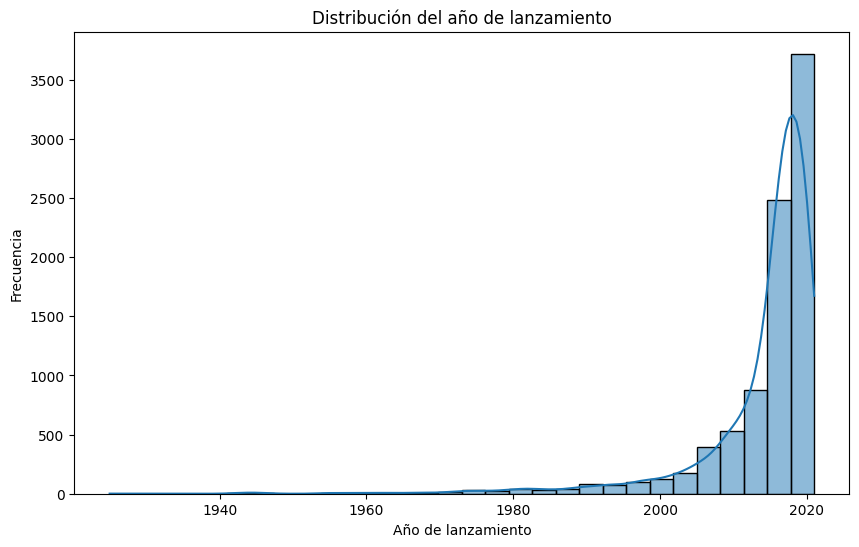

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=datos,
    x="release_year",
    bins=30,
    kde=True
)

plt.title("Distribución del año de lanzamiento")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Frecuencia")

plt.show()

La variable release_year presenta una media de 2014.18 años y una mediana de 2017, lo que indica que los contenidos se concentran principalmente en años recientes. Los años van desde 1925 hasta 2021, mostrando una amplitud temporal considerable. Sin embargo, el 50 % central de los contenidos se encuentra entre 2013 y 2019, con un rango intercuartílico de 6 años, lo que indica una concentración relativamente alta de los datos en este periodo. La desviación estándar de aproximadamente 8.83 años muestra una dispersión moderada alrededor de la media.  

### Frecuencias de variables categóricas (variables categóricas)

Para este caso solo se analizarán type y rating para el ejemplo, pero cabe resaltar que algunas variables no es necesaria analizarlas en bruto, como es el caso de cast, description o listed_in porque tienen muchas categorías distintas o unicas.  

- **Type**

In [13]:
tabla_type = pd.DataFrame({
    "Frecuencia": datos["type"].value_counts(),
    "Porcentaje (%)": datos["type"].value_counts(normalize=True).mul(100).round(2)
})

tabla_type

,Frecuencia,Porcentaje (%)
type,,
Movie,6126,69.69
TV Show,2664,30.31


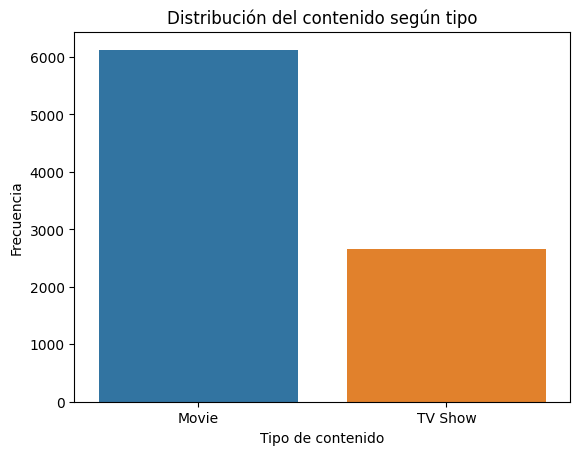

In [14]:
sns.countplot(
    data=datos,
    x="type"
)

plt.title("Distribución del contenido según tipo")
plt.xlabel("Tipo de contenido")
plt.ylabel("Frecuencia")
plt.show()

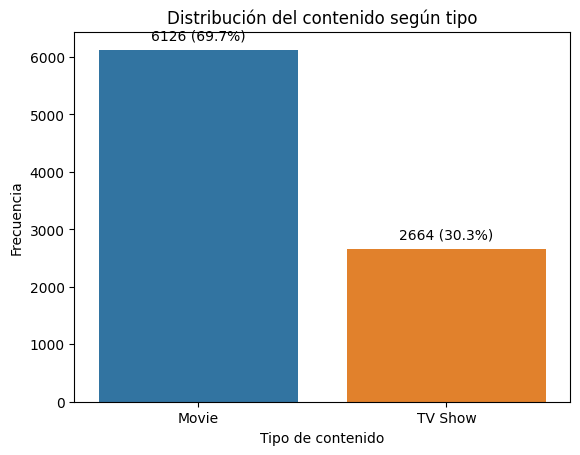

In [15]:
#Otra forma para visualizar el gráfico

ax = sns.countplot(data=datos, x="type")
total = len(datos)

for p in ax.patches:
    conteo = int(p.get_height())
    porcentaje = f"{100 * conteo / total:.1f}%"

    ax.annotate(f'{conteo} ({porcentaje})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points')

plt.title("Distribución del contenido según tipo")
plt.xlabel("Tipo de contenido")
plt.ylabel("Frecuencia")
plt.show()

- **Rating**

In [16]:
tabla_rating = pd.DataFrame({
    "Frecuencia": datos["rating"].value_counts(),
    "Porcentaje (%)": datos["rating"].value_counts(normalize=True).mul(100).round(2)
})

tabla_rating

,Frecuencia,Porcentaje (%)
rating,,
TV-MA,3205,36.46
TV-14,2157,24.54
TV-PG,861,9.80
R,799,9.09
PG-13,490,5.57
TV-Y7,333,3.79
TV-Y,306,3.48
PG,287,3.27
TV-G,220,2.50


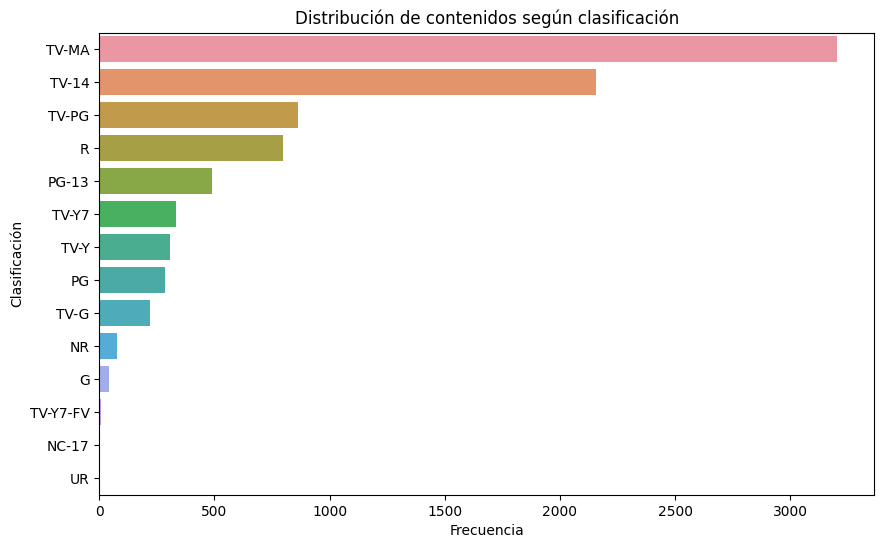

In [17]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=datos,
    y="rating",
    order=datos["rating"].value_counts().index
)

plt.title("Distribución de contenidos según clasificación")
plt.xlabel("Frecuencia")
plt.ylabel("Clasificación")
plt.show()

## Análisis Descriptivo Bivariado  

### Categórica vs Categórica  

El mejor ejemplo para esta sección es la variable type vs rating. Para ello se hace la siguiente tabla de contingencia:

In [18]:
tabla_contingencia = pd.crosstab(
    datos["type"],
    datos["rating"],
    margins=True,
    margins_name="Total"
)

tabla_contingencia

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR,Total
type,,,,,,,,,,,,,,,
Movie,41,3,75,287,490,797,1427,126,2062,540,131,139,5,3,6126
TV Show,0,0,4,0,0,2,730,94,1143,321,175,194,1,0,2664
Total,41,3,79,287,490,799,2157,220,3205,861,306,333,6,3,8790


In [19]:
tabla_porcentajes = pd.crosstab(
    datos["type"],
    datos["rating"],
    normalize="index"
) * 100

tabla_porcentajes.round(2)

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,0.67,0.05,1.22,4.68,8.0,13.01,23.29,2.06,33.66,8.81,2.14,2.27,0.08,0.05
TV Show,0.00,0.00,0.15,0.00,0.0,0.08,27.40,3.53,42.91,12.05,6.57,7.28,0.04,0.00


La tabla de contingencia muestra la distribución de las clasificaciones (rating) según el tipo de contenido. En las películas, predominan las clasificaciones TV-MA (33.66%) y TV-14 (23.29%), seguidas por R (13.01%). En las series, también predomina TV-MA (42.91%), seguida de TV-14 (27.40%) y TV-PG (12.05%). En general, se observa que las clasificaciones más frecuentes presentan una distribución diferente entre películas y series, aunque TV-MA es la categoría predominante en ambos tipos.  

### Categórica vs numérica  

Se analizará la variable type vs release_year  

In [20]:
datos.groupby("type")["release_year"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,6126.0,2013.120144,9.681723,1942.0,2012.0,2016.0,2018.0,2021.0
TV Show,2664.0,2016.627628,5.735194,1925.0,2016.0,2018.0,2020.0,2021.0


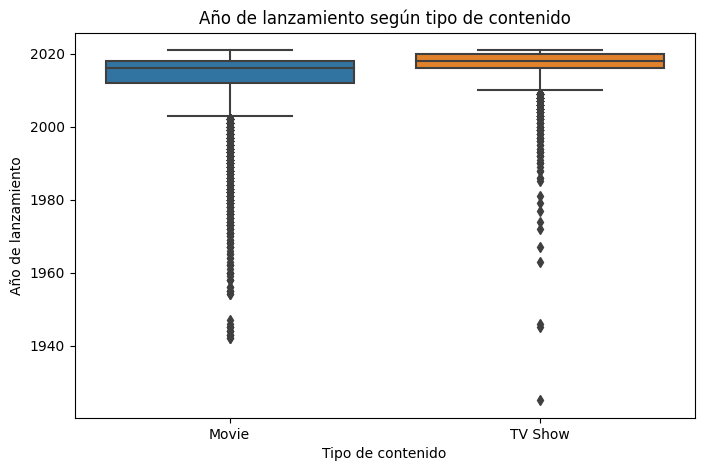

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=datos,
    x="type",
    y="release_year"
)

plt.title("Año de lanzamiento según tipo de contenido")
plt.xlabel("Tipo de contenido")
plt.ylabel("Año de lanzamiento")

plt.show()

Al comparar el año de lanzamiento según el tipo de contenido, se observa que las series presentan una mediana de 2018, superior a la mediana de 2016 de las películas. Además, el 50% central de las películas se encuentra entre 2012 y 2018, mientras que en las series se encuentra entre 2016 y 2020, lo que indica que las series del catálogo tienden a ser más recientes. Las películas presentan una mayor dispersión, con una desviación estándar de 9.68 años, frente a 5.74 años para las series. En ambos grupos se observan numerosos valores atípicos hacia años anteriores, especialmente en las películas, correspondientes a contenidos producidos varias décadas antes de los años predominantes del catálogo.  